In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


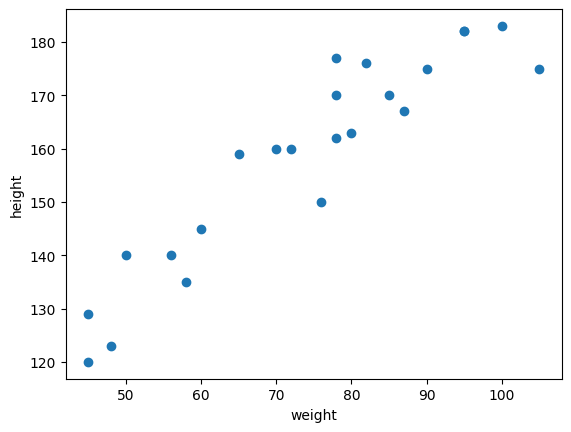

In [8]:
# Scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('weight')
plt.ylabel('height')
plt.show()

In [9]:
# finding correlation 
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


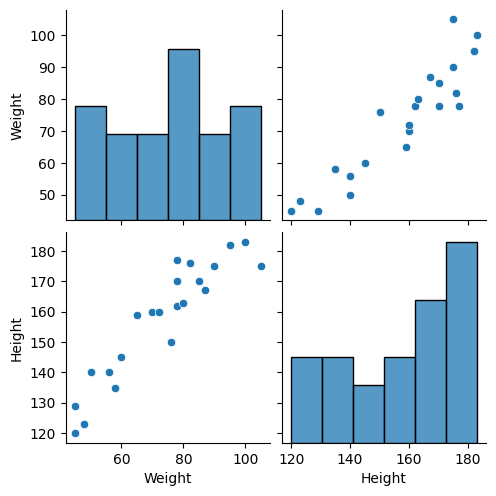

In [10]:
# seaborn for visualization 
import seaborn as sns
sns.pairplot(df)

In [ ]:
# splitting into independent and dependent features 
X = df[['Weight']] # always make sure that the independent feature should be a dataframe or 2 Dimentional array and not a series object 
X.head()
y = df['Height'] # this is a output or dependent feature so it is ok for it to be a series object or 1 d array 

In [14]:
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [15]:
# Train Test Splitting for overfitting and underfitting 
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
X_train.shape

(17, 1)

In [17]:
# Standardization 
from sklearn.preprocessing import StandardScaler


In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [19]:
X_test = scaler.transform(X_test)

In [20]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [21]:
# Applying simple linear regression 
from sklearn.linear_model import LinearRegression

In [24]:
regression = LinearRegression(n_jobs=-1)

In [25]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
print(f"Coefficient or Slope : {regression.coef_}")
print(f"Intercept : {regression.intercept_}")

Coefficient or Slope : [17.2982057]
Intercept : 156.47058823529412


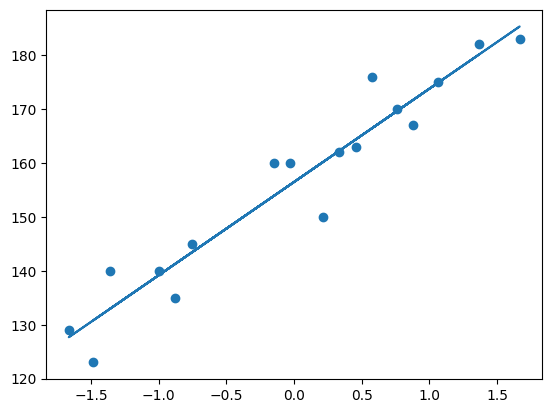

In [31]:
# Plotting training data plot for best fit line 
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

### prediction for test data : 
1. predicted height output = intercept + coef_ * (weight)
2. y_pred_test = 156.47 + 17.29 * (X_test)

In [32]:
# Prediction for test data : 
y_pred = regression.predict(X_test)

In [33]:
# performance metrics : 
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [34]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("mse : ",mse)
print("mae : ",mae)
print("rmse : ",rmse)

mse :  114.84069295228699
mae :  9.66512588679501
rmse :  10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [35]:
from sklearn.metrics import r2_score

In [36]:
score = r2_score(y_test, y_pred)

In [37]:
score

0.7360826717981276

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [38]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [40]:
# Prediction for new data : 
regression.predict(scaler.transform([[72]]))

c:\Users\patil\OneDrive\Desktop\Udemy ML\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])